In [8]:
import os
import gc
import json
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, InputLayer
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans"})
ACCENT  = "#7C3AED"
ACCENT2 = "#06B6D4"
RED     = "#EF4444"
GREEN   = "#22C55E"
AMBER   = "#F59E0B"

In [9]:
# ============================================================
# 0 -- Config
# ============================================================
# Reuses the frozen Hyperband-selected architecture (tuner_results.py /
# hyperparameter_tuning.ipynb) for every retrain below. This notebook does
# NOT re-run hyperparameter search and does NOT overwrite
# models/signlingo_gru_best.h5 -- it only runs controlled comparison retrains.
DATA_DIR        = "features"
SEQUENCE_LENGTH = 30
FEATURES_DIM    = 447
MAX_SAMPLES     = 110
RANDOM_STATE    = 42
BATCH_SIZE      = 32
EPOCHS          = 150

# Best hyperparameters selected by the Hyperband search (see tuner_results.py)
GRU1, GRU2, DROPOUT, L2_RATE, USE_REC_L2, LR = 32, 256, 0.3, 1e-4, False, 1e-3

# Feature layout within the 447-dim vector, per extraction.py's concat order
# (pose + face + left_hand + right_hand):
POSE_SLICE = slice(0, 99)     # 33 landmarks x 3
FACE_SLICE = slice(99, 321)   # 74 landmarks x 3
LH_SLICE   = slice(321, 384)  # 21 landmarks x 3
RH_SLICE   = slice(384, 447)  # 21 landmarks x 3

# The "Full" ablation variant below is retrained fresh (not reused from
# models/signlingo_gru_best.h5) so all 3 variants share one identical split.
# It should land near the paper's headline 99.32% -- if it deviates by more
# than this, treat it as a harness bug, not a real ablation finding.
FULL_VARIANT_SANITY_TOLERANCE_PP = 3.0  # percentage points

In [10]:
# ============================================================
# 1 -- Signer-group classifier & class-group lists
# ============================================================
# Signer identity is not recorded as metadata anywhere in this project; it is
# reconstructed from filename convention, confirmed against the paper's raw
# per-class counts (110-119) and the primary/secondary subset description:
#   - 3 signers contribute ~20-26 sequences/class each (their union is the
#     paper's "primary subset", 60/class)
#   - 1 signer contributes ~50-60 sequences/class alone (the paper's
#     "secondary subset") -- this is the BISINDO_*.npy group, most likely
#     sourced from the public "BISINDO 40 Kata mp4" Kaggle dataset.
def classify_signer(fname: str) -> str:
    stem = os.path.splitext(fname)[0]
    stem = re.sub(r"\s*\(\d+\)$", "", stem)  # strip Windows copy suffix " (1)"
    if stem.upper().startswith("BISINDO_"):
        return "Signer_D_bisindo"
    if re.fullmatch(r"\d+", stem):
        return "Signer_A_numeric"
    if re.search(r"-\d+$", stem):
        return "Signer_B_dash"
    if re.search(r"_\d+$", stem):
        return "Signer_C_underscore"
    return "Signer_UNK"


# NMS-focused / standard-manual split -- UNVERIFIED RECONSTRUCTION.
# The paper states 20 NMS-focused + 20 standard-manual classes but the full
# list isn't recorded anywhere in this repo (only 4 examples are named in the
# paper text: marah, sedih, bingung, bagaimana). This list was reconstructed
# from cross-linguistic NMS literature (wh-question brow/head marking,
# emotion/attitude facial affect, head-tilt height marking).
#
# A quantitative sanity check (mean frame-to-frame face-landmark motion per
# class, computed from this project's own features/*.npy) was run against
# it and was INCONCLUSIVE: several classes in this list, including the
# paper's own named examples "marah" and "bagaimana", show some of the
# LOWEST motion magnitudes of all 40 classes. This does not mean the split is
# wrong -- most NMS marking (a furrowed brow held through a sign, a raised-
# eyebrow question face) is a held/static expression, not a repeated
# movement, so frame-to-frame motion magnitude mostly captures the wrong
# thing and cannot confirm or contradict this list either way.
# Treat this breakdown as exploratory, not verified ground truth.
NMS_FOCUSED_CLASSES = {
    "Apa", "Bagaimana", "Berapa", "Dimana", "Kapan", "Kemana", "Siapa",
    "Bingung", "Marah", "Ramah", "Sabar", "Sedih", "Senang", "Baik",
    "Apa Kabar", "Halo", "Terima Kasih", "Tinggi", "Pendek", "Melihat",
}

In [11]:
# ============================================================
# 2 -- Load dataset with signer-group labels attached
# ============================================================
print("Loading dataset with signer-group labels...")
actions = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
num_classes = len(actions)
label_map = {a: i for i, a in enumerate(actions)}

sequences, labels, groups = [], [], []
for action in actions:
    action_path = os.path.join(DATA_DIR, action)
    for f in tqdm([f for f in os.listdir(action_path) if f.endswith(".npy")],
                  desc=f"  {action:<15}", leave=False):
        seq = np.load(os.path.join(action_path, f))
        if seq.shape == (SEQUENCE_LENGTH, FEATURES_DIM):
            sequences.append(seq)
            labels.append(label_map[action])
            groups.append(classify_signer(f))

X = np.array(sequences, dtype=np.float32)
y_int = np.array(labels)
group_all = np.array(groups)

n_unk = int(np.sum(group_all == "Signer_UNK"))
print(f"  Loaded {len(X)} raw sequences ({n_unk} unclassifiable filenames -> Signer_UNK)")

# Balance to MAX_SAMPLES/class (first N encountered), identical rule to
# tuner_results.py / kfold_cross_validation.ipynb, so the ablation's "Full"
# variant is comparable to the frozen headline model.
idx = []
for i in range(num_classes):
    idx.extend(np.where(y_int == i)[0][:MAX_SAMPLES])
X, y_int, group_all = X[idx], y_int[idx], group_all[idx]
y_oh = to_categorical(y_int, num_classes=num_classes).astype(np.float32)
print(f"  Balanced set: {X.shape[0]} samples across {num_classes} classes ({MAX_SAMPLES}/class)")

# Class x signer-group coverage check -- a class covered by only 1 signer
# group would go zero-shot in that signer's LOSO fold. Verified clean on the
# raw data before building this notebook; re-checked here since balancing
# (which favors groups that sort earlier alphabetically) can change that.
print("\nClass x signer-group coverage check (post-balancing):")
bad_classes = []
for i, action in enumerate(actions):
    present = set(group_all[y_int == i]) - {"Signer_UNK"}
    if len(present) < 4:
        bad_classes.append((action, present))
if bad_classes:
    print(f"  WARNING: {len(bad_classes)} class(es) not covered by all 4 signer groups:")
    for action, present in bad_classes:
        print(f"    {action}: only {sorted(present)}")
else:
    print("  OK -- every class has sequences from all 4 signer groups.")

Loading dataset with signer-group labels...


  Loaded 4628 raw sequences (7 unclassifiable filenames -> Signer_UNK)
  Balanced set: 4400 samples across 40 classes (110/class)

Class x signer-group coverage check (post-balancing):
    Marah: only ['Signer_A_numeric', 'Signer_B_dash', 'Signer_D_bisindo']


In [12]:
# ============================================================
# 3 -- Augmentation (train-only, x3) -- dimension-agnostic version of the
# helper in kfold_cross_validation.ipynb, so it works for every ablation
# feature width (126 / 225 / 447), not just the full 447-dim vector.
# ============================================================
def augment_sequence(data):
    n_frames, n_feat = data.shape
    aug = data.copy().astype(np.float32)
    aug += np.random.normal(0, 0.005, aug.shape).astype(np.float32)
    aug = aug.reshape(n_frames, -1, 3)
    aug *= np.float32(np.random.uniform(0.95, 1.05))
    angle = np.radians(np.random.uniform(3, 5) * np.random.choice([-1, 1]))
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    aug = np.dot(aug, R).reshape(n_frames, n_feat)
    new_len = int(n_frames * np.random.uniform(0.9, 1.1))
    out = np.zeros((n_frames, n_feat), dtype=np.float32)
    for f in range(n_feat):
        out[:, f] = np.interp(
            np.linspace(0, n_frames - 1, n_frames),
            np.linspace(0, n_frames - 1, new_len),
            np.interp(np.linspace(0, n_frames - 1, new_len), np.arange(n_frames), aug[:, f]))
    return out


def augment_x3(X_tr, y_tr):
    n = X_tr.shape[0]
    n_frames, n_feat = X_tr.shape[1], X_tr.shape[2]
    Xa = np.empty((n * 3, n_frames, n_feat), dtype=np.float32)
    ya = np.empty((n * 3, y_tr.shape[1]), dtype=np.float32)
    Xa[:n], ya[:n] = X_tr, y_tr
    for i, seq in enumerate(X_tr):
        Xa[n + i] = augment_sequence(seq)
        Xa[2 * n + i] = augment_sequence(seq)
    ya[n:2 * n] = y_tr
    ya[2 * n:3 * n] = y_tr
    perm = np.random.permutation(len(Xa))
    return Xa[perm], ya[perm]

In [13]:
# ============================================================
# 4 -- Model builder (fixed best hyperparameters, parametrized input width)
# and the shared train+eval routine used by both Part A and Part B below.
# ============================================================
def build_model(input_dim):
    kreg = regularizers.l2(L2_RATE)
    rreg = regularizers.l2(L2_RATE) if USE_REC_L2 else None
    model = Sequential([
        InputLayer(input_shape=(SEQUENCE_LENGTH, input_dim)),
        GRU(GRU1, return_sequences=True, name="gru_1",
            kernel_regularizer=kreg, recurrent_regularizer=rreg),
        Dropout(DROPOUT, name="dropout_1"),
        GRU(GRU2, return_sequences=False, name="gru_2",
            kernel_regularizer=kreg, recurrent_regularizer=rreg),
        Dropout(DROPOUT, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output",
              kernel_regularizer=regularizers.l2(L2_RATE)),
    ], name="SignLingo_GRU_Ablation")
    model.compile(optimizer=Adam(LR), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def train_and_eval(X_tr, y_tr, X_val, y_val, X_te, y_te, input_dim):
    tf.keras.backend.clear_session()
    model = build_model(input_dim)
    model.fit(
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
          .shuffle(len(X_tr)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
        validation_data=tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
        epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
        ],
        verbose=0,
    )
    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_te.argmax(axis=1)
    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "loss": log_loss(y_true, probs, labels=list(range(num_classes))),
    }
    del model
    gc.collect()
    return row, y_true, y_pred

In [14]:
# ============================================================
# 5 -- PART A: 3-way feature ablation (hand-only / hand+pose / full)
# ============================================================
# One shared stratified 80/10/10 split (indices only) so every variant sees
# the exact same sequences -- only the feature columns differ.
all_idx = np.arange(len(X))
train_idx, tmp_idx = train_test_split(all_idx, test_size=0.20, stratify=y_int, random_state=RANDOM_STATE)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=y_int[tmp_idx], random_state=RANDOM_STATE)

VARIANTS = {
    "Hand-only":             [LH_SLICE, RH_SLICE],
    "Hand+Pose":             [POSE_SLICE, LH_SLICE, RH_SLICE],
    "Full (Hand+Pose+Face)": [POSE_SLICE, FACE_SLICE, LH_SLICE, RH_SLICE],
}

def slice_features(arr, slices):
    # arr is (N, 30, 447) -- slice the feature axis (last), not the frame axis.
    return np.concatenate([arr[:, :, s] for s in slices], axis=-1)

ablation_rows = []
for name, slices in VARIANTS.items():
    print(f"\n{'='*60}\nABLATION: {name}\n{'='*60}")
    Xv = slice_features(X, slices)
    input_dim = Xv.shape[-1]  # Xv is (N, 30, features) -- last axis, not frame axis

    X_tr, y_tr = Xv[train_idx], y_oh[train_idx]
    X_val, y_val = Xv[val_idx], y_oh[val_idx]
    X_te, y_te = Xv[test_idx], y_oh[test_idx]
    X_tr, y_tr = augment_x3(X_tr, y_tr)
    print(f"  dim={input_dim}  train(aug)={len(X_tr)}  val={len(X_val)}  test={len(X_te)}")

    row, y_true, y_pred = train_and_eval(X_tr, y_tr, X_val, y_val, X_te, y_te, input_dim)
    row["variant"] = name
    row["input_dim"] = input_dim

    # Per-class-group breakdown (NMS-focused vs standard-manual)
    test_actions = np.array([actions[i] for i in y_true])
    is_nms = np.array([a in NMS_FOCUSED_CLASSES for a in test_actions])
    row["accuracy_nms_focused"] = float(accuracy_score(y_true[is_nms], y_pred[is_nms])) if is_nms.any() else None
    row["accuracy_manual"] = float(accuracy_score(y_true[~is_nms], y_pred[~is_nms])) if (~is_nms).any() else None

    ablation_rows.append(row)
    print(f"  acc={row['accuracy']*100:.2f}%  f1={row['f1']:.4f}  "
          f"NMS-focused acc={row['accuracy_nms_focused']*100:.2f}%  "
          f"manual acc={row['accuracy_manual']*100:.2f}%")

# Sanity check: the "Full" variant should reproduce the paper's headline
# ~99.32% test accuracy. This is a fresh retrain (stochastic), not the frozen
# models/signlingo_gru_best.h5, so an exact match isn't expected -- but a
# large deviation signals a harness bug, not a real ablation finding.
full_row = next(r for r in ablation_rows if r["variant"] == "Full (Hand+Pose+Face)")
deviation_pp = abs(full_row["accuracy"] * 100 - 99.32)
print(f"\nSanity check: Full-variant accuracy = {full_row['accuracy']*100:.2f}% "
      f"(headline = 99.32%, deviation = {deviation_pp:.2f} pp)")
if deviation_pp > FULL_VARIANT_SANITY_TOLERANCE_PP:
    print(f"  WARNING: deviation exceeds {FULL_VARIANT_SANITY_TOLERANCE_PP} pp tolerance -- "
          f"treat the ablation comparison with caution, check the harness before trusting deltas.")
else:
    print("  OK -- within tolerance.")

with open("ablation_results.json", "w") as fh:
    json.dump({
        "note": "Single-split point estimate, not cross-validated -- no CI on deltas. "
                "NMS-focused/manual class split is an unverified reconstruction "
                "(see NMS_FOCUSED_CLASSES definition above).",
        "variants": ablation_rows,
    }, fh, indent=2)
print("\nSaved -> ablation_results.json")


ABLATION: Hand-only
  dim=126  train(aug)=10560  val=440  test=440
  acc=98.86%  f1=0.9885  NMS-focused acc=98.64%  manual acc=99.09%

ABLATION: Hand+Pose
  dim=225  train(aug)=10560  val=440  test=440
  acc=99.32%  f1=0.9932  NMS-focused acc=98.64%  manual acc=100.00%

ABLATION: Full (Hand+Pose+Face)
  dim=447  train(aug)=10560  val=440  test=440
  acc=99.09%  f1=0.9909  NMS-focused acc=98.64%  manual acc=99.55%

Sanity check: Full-variant accuracy = 99.09% (headline = 99.32%, deviation = 0.23 pp)
  OK -- within tolerance.

Saved -> ablation_results.json


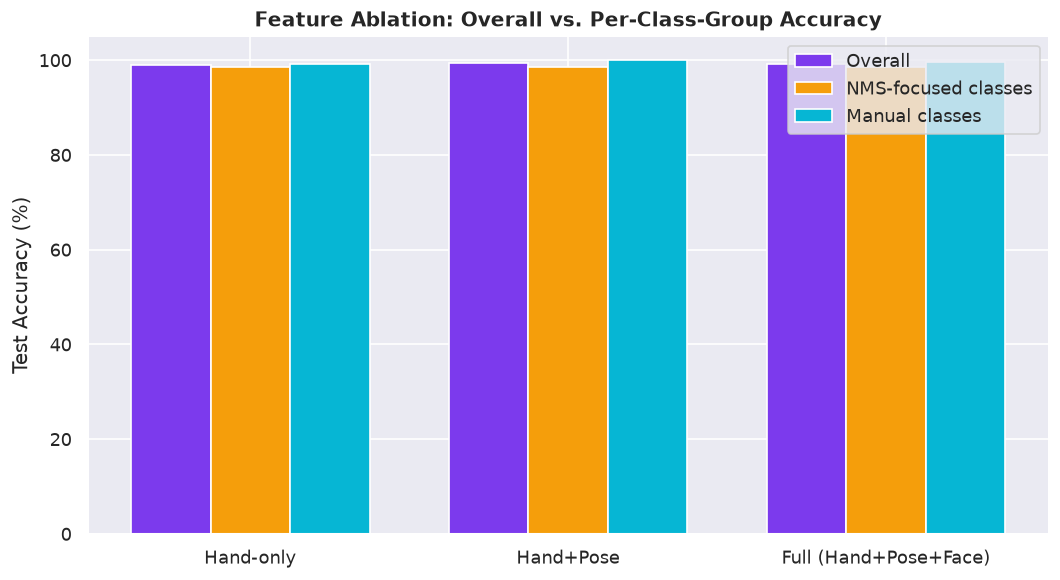

In [15]:
# ============================================================
# 6 -- Ablation comparison chart
# ============================================================
names = [r["variant"] for r in ablation_rows]
accs = [r["accuracy"] * 100 for r in ablation_rows]
nms_accs = [r["accuracy_nms_focused"] * 100 for r in ablation_rows]
manual_accs = [r["accuracy_manual"] * 100 for r in ablation_rows]

x_pos = np.arange(len(names))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_pos - w, accs, w, label="Overall", color=ACCENT)
ax.bar(x_pos, nms_accs, w, label="NMS-focused classes", color=AMBER)
ax.bar(x_pos + w, manual_accs, w, label="Manual classes", color=ACCENT2)
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Feature Ablation: Overall vs. Per-Class-Group Accuracy", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 7 -- PART B: Leave-One-Signer-Out (LOSO) cross-validation
# ============================================================
# Uses the full 447-dim feature set only (matches the headline model). Each
# fold holds out 1 signer group entirely for testing; the remaining 3 signer
# groups' sequences are pooled for training with a nested stratified
# validation carve-out (~12%) for early stopping. Augmentation stays
# train-only; the held-out signer's sequences are never augmented.
# Hyperparameters are frozen (not re-tuned per fold), same as the existing
# 5-fold script.
known_mask = group_all != "Signer_UNK"
X_loso, y_int_loso, y_oh_loso, group_loso = X[known_mask], y_int[known_mask], y_oh[known_mask], group_all[known_mask]
n_dropped = int((~known_mask).sum())
if n_dropped:
    print(f"Dropping {n_dropped} sequences with unclassifiable signer identity from LOSO "
          f"(they stay in the Part A ablation pool above, which doesn't need signer identity).")

logo = LeaveOneGroupOut()
loso_rows = []
for train_idx_l, test_idx_l in logo.split(X_loso, y_int_loso, group_loso):
    held_out_signer = group_loso[test_idx_l][0]
    print(f"\n{'='*60}\nLOSO FOLD: held out {held_out_signer}\n{'='*60}")

    X_te, y_te = X_loso[test_idx_l], y_oh_loso[test_idx_l]
    X_trf, y_trf = X_loso[train_idx_l], y_oh_loso[train_idx_l]
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_trf, y_trf, test_size=0.12, stratify=y_int_loso[train_idx_l], random_state=RANDOM_STATE)
    X_tr, y_tr = augment_x3(X_tr, y_tr)
    print(f"  held-out test={len(X_te)}  train(aug)={len(X_tr)}  val={len(X_val)}")

    row, y_true, y_pred = train_and_eval(X_tr, y_tr, X_val, y_val, X_te, y_te, FEATURES_DIM)
    row["held_out_signer"] = held_out_signer
    row["n_test"] = int(len(X_te))
    row["n_train_before_aug"] = int(len(X_trf) - len(X_val))
    loso_rows.append(row)
    print(f"  acc={row['accuracy']*100:.2f}%  f1={row['f1']:.4f}  CE-loss={row['loss']:.4f}")

def mean_std(rows, key):
    v = np.array([r[key] for r in rows])
    return float(v.mean()), float(v.std())

loso_acc_mean, loso_acc_std = mean_std(loso_rows, "accuracy")
print(f"\n{'='*60}\nLOSO SUMMARY (4 signer-held-out folds)\n{'='*60}")
for key in ["accuracy", "precision", "recall", "f1", "loss"]:
    m, sd = mean_std(loso_rows, key)
    scale = 100 if key != "loss" else 1
    print(f"  {key:10s}: {m*scale:.4f}  +/- {sd*scale:.4f}")

print("\nNOTE: folds are NOT equally weighted. The fold that holds out the "
      "~50-60/class 'secondary subset' signer trains on roughly half the "
      "usual data and is expected to drop the most -- that's a real training-"
      "volume effect, not noise, and should be reported per-fold, not smoothed "
      "into the mean.")

if os.path.exists("kfold_results.json"):
    with open("kfold_results.json") as fh:
        kfold_summary = json.load(fh)["summary"]["accuracy"]
    print(f"\nStratified 5-fold accuracy: {kfold_summary['mean']*100:.2f}% +/- {kfold_summary['std']*100:.2f}%")
    print(f"LOSO 4-fold accuracy:       {loso_acc_mean*100:.2f}% +/- {loso_acc_std*100:.2f}%")
    print(f"Gap (stratified - LOSO):    {(kfold_summary['mean']-loso_acc_mean)*100:.2f} pp")

results = {"folds": loso_rows, "summary": {k: dict(zip(["mean", "std"], mean_std(loso_rows, k)))
                                            for k in ["accuracy", "precision", "recall", "f1", "loss"]}}
with open("loso_results.json", "w") as fh:
    json.dump(results, fh, indent=2)
print("\nSaved -> loso_results.json")

Dropping 6 sequences with unclassifiable signer identity from LOSO (they stay in the Part A ablation pool above, which doesn't need signer identity).

LOSO FOLD: held out Signer_A_numeric
  held-out test=977  train(aug)=9018  val=411
  acc=46.67%  f1=0.4117  CE-loss=3.1457

LOSO FOLD: held out Signer_B_dash
  held-out test=781  train(aug)=9537  val=434
  acc=19.33%  f1=0.1468  CE-loss=6.0868

LOSO FOLD: held out Signer_C_underscore
  held-out test=674  train(aug)=9819  val=447
  acc=46.29%  f1=0.4169  CE-loss=3.1258

LOSO FOLD: held out Signer_D_bisindo
  held-out test=1962  train(aug)=6420  val=292
  acc=53.01%  f1=0.4743  CE-loss=2.7248

LOSO SUMMARY (4 signer-held-out folds)
  accuracy  : 41.3264  +/- 12.9743
  precision : 44.1121  +/- 15.4884
  recall    : 41.3264  +/- 12.9743
  f1        : 36.2436  +/- 12.6871
  loss      : 3.7708  +/- 1.3477

NOTE: folds are NOT equally weighted. The fold that holds out the ~50-60/class 'secondary subset' signer trains on roughly half the usual d

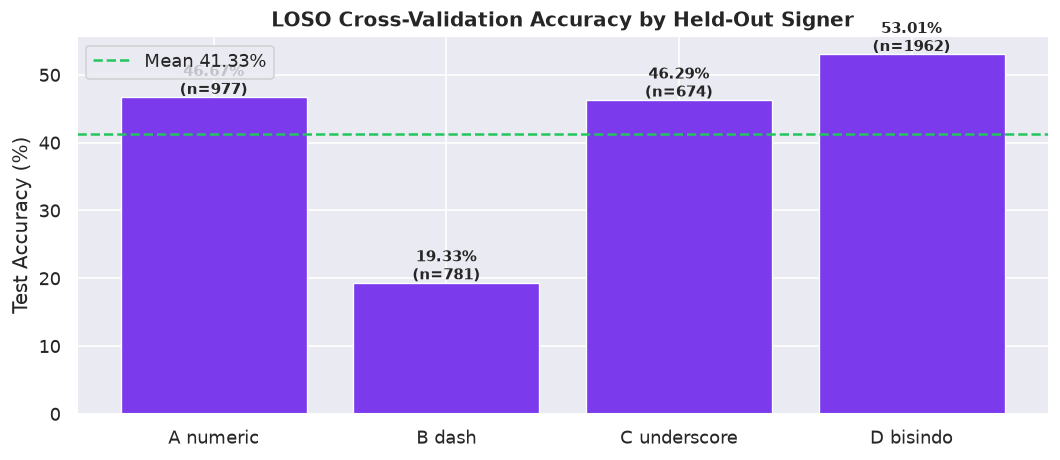

In [17]:
# ============================================================
# 8 -- Per-signer LOSO accuracy chart
# ============================================================
labels_ = [r["held_out_signer"].replace("Signer_", "").replace("_", " ") for r in loso_rows]
accs = [r["accuracy"] * 100 for r in loso_rows]
n_test = [r["n_test"] for r in loso_rows]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels_, accs, color=ACCENT, edgecolor="white", linewidth=0.8)
ax.axhline(loso_acc_mean * 100, color=GREEN, lw=1.5, linestyle="--",
           label=f"Mean {loso_acc_mean*100:.2f}%")
for bar, v, n in zip(bars, accs, n_test):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{v:.2f}%\n(n={n})", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("LOSO Cross-Validation Accuracy by Held-Out Signer", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()